## <small>
Copyright (c) 2017-21 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning: A Visual Approach
## by Andrew Glassner, https://glassner.com
### Order: https://nostarch.com/deep-learning-visual-approach
### GitHub: https://github.com/blueberrymusic
------

### What's in this notebook

This notebook is provided as a “behind-the-scenes” look at code used to make some of the figures in this chapter. It is cleaned up a bit from the original code that I hacked together, and is only lightly commented. I wrote the code to be easy to interpret and understand, even for those who are new to Python. I tried never to be clever or even more efficient at the cost of being harder to understand. The code is in Python3, using the versions of libraries as of April 2021.

This notebook may contain additional code to create models and images not in the book. That material is included here to demonstrate additional techniques.

Note that I've included the output cells in this saved notebook, but Jupyter doesn't save the variables or data that were used to generate them. To recreate any cell's output, evaluate all the cells from the start up to that cell. A convenient way to experiment is to first choose "Restart & Run All" from the Kernel menu, so that everything's been defined and is up to date. Then you can experiment using the variables, data, functions, and other stuff defined in this notebook.

### A note on variation of output

Note as always that due to the use of random numbers, some of the results here may differ from those in the book (since I re-ran everything to prepare this notebook), and will probably be different yet again if you run this notebook.

### Chapter 18: Autoencoders - Notebook 3: MNIST 2

In [2]:
from keras.models import Sequential, Model
from keras.layers import Conv2D, Dense, Input, MaxPooling2D, UpSampling2D
from keras.utils import to_categorical # Changed from np_utils to to_categorical
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import h5py
from pathlib import Path

from keras import backend as keras_backend
keras_backend.set_image_data_format('channels_last')

In [3]:
# Workaround for Keras issues on Mac computers (you can comment this
# out if you're not on a Mac, or not having problems)
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [12]:
# Make a File_Helper for saving and loading files.
# Make a File_Helper for saving and loading files.

save_files = False

try:
    import os, sys, inspect

    current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
    sys.path.insert(0, os.path.dirname(current_dir))  # path to parent dir

    from DLBasics_Utilities import File_Helper
    print("Using real DLBasics_Utilities.File_Helper")

except ModuleNotFoundError:
    import os

    class File_Helper:
        def __init__(self, save_files=False):
            self.save_files = save_files
            # change this if your data / images are in another folder
            self.INPUT_DIR = os.getcwd()

        def get_input_data_dir(self):
            d = self.INPUT_DIR
            print(f"get_input_data_dir (stub) -> {d}")
            return d

        def get_input_file_path(self, filename):
            path = os.path.join(self.INPUT_DIR, filename)
            print(f"get_input_file_path (stub) -> {path}")
            return path

        def save_figure(self, fig, filename, *args, **kwargs):
            if filename:
                print(f"save_figure (stub) – would save '{filename}', but skipping.")

        def load_model_weights(self, model, filename):
            print(f"load_model_weights (stub) – would load '{filename}', but skipping.")
            return False # Indicate that weights were not loaded, so training should proceed

        def save_model_weights(self, model, filename):
            if self.save_files:
                print(f"save_model_weights (stub) – would save '{filename}', but skipping.")

        def __repr__(self):
            return f"<Stub File_Helper save_files={self.save_files}, INPUT_DIR='{self.INPUT_DIR}'>"

    print("Using stub File_Helper (DLBasics_Utilities not found)")

file_helper = File_Helper(save_files)
file_helper

Using stub File_Helper (DLBasics_Utilities not found)


<Stub File_Helper save_files=False, INPUT_DIR='/content'>

In [8]:
random_seed = 42
np.random.seed(random_seed)

# load the MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
image_height = X_train.shape[1]
image_width = X_train.shape[2]
number_of_pixels = image_height * image_width

# cast the sample data to the current Keras floating-point type
X_train = X_train.astype(keras_backend.floatx())
X_test = X_test.astype(keras_backend.floatx())

# reshape to 2D grid, one line per image
X_train = X_train.reshape(X_train.shape[0], number_of_pixels)
X_test = X_test.reshape(X_test.shape[0], number_of_pixels)

# scale data to range [0, 1]
X_train /= 255.0
X_test /= 255.0

# reshape sample data to 4D tensor using channels_last convention
X_train = X_train.reshape(X_train.shape[0], image_height, image_width, 1)
X_test = X_test.reshape(X_test.shape[0], image_height, image_width, 1)

# replace label data with one-hot encoded versions
number_of_classes = 1 + max(np.append(y_train, y_test))
y_train = to_categorical(y_train, number_of_classes)
y_test = to_categorical(y_test, number_of_classes)

In [9]:
CAE_encoder_input = Input(shape=(28,28, 1))
CAE_encoder_conv_1 = Conv2D(16, (3, 3), activation='relu', padding='same')
CAE_encoder_pool_1 = MaxPooling2D((2,2), padding='same')
CAE_encoder_conv_2 = Conv2D(8, (3, 3), activation='relu', padding='same')
CAE_encoder_pool_2 = MaxPooling2D((2,2), padding='same')
CAE_encoder_output = Conv2D(3, (3, 3), activation='relu', padding='same')

CAE_decoder_up_1 = UpSampling2D((2,2))
CAE_decoder_conv_1 = Conv2D(16, (3, 3), activation='relu', padding='same')
CAE_decoder_up_2 = UpSampling2D((2,2))
CAE_decoder_output = Conv2D(1, (3, 3), activation='sigmoid', padding='same')

CAE_encoder_step_1 = CAE_encoder_conv_1(CAE_encoder_input)
CAE_encoder_step_2 = CAE_encoder_pool_1(CAE_encoder_step_1)
CAE_encoder_step_3 = CAE_encoder_conv_2(CAE_encoder_step_2)
CAE_encoder_step_4 = CAE_encoder_pool_2(CAE_encoder_step_3)
CAE_encoder_step_5 = CAE_encoder_output(CAE_encoder_step_4)

CAE_decoder_step_1 = CAE_decoder_up_1(CAE_encoder_step_5)
CAE_decoder_step_2 = CAE_decoder_conv_1(CAE_decoder_step_1)
CAE_decoder_step_3 = CAE_decoder_up_2(CAE_decoder_step_2)
CAE_decoder_step_4 = CAE_decoder_output(CAE_decoder_step_3)


Conv_AE = Model(CAE_encoder_input, CAE_decoder_step_4)
Conv_AE.compile(optimizer='adadelta', loss='binary_crossentropy')


Conv_AE_encoder_only_model = Model(CAE_encoder_input, CAE_encoder_step_5)

Conv_AE_decoder_only_input = Input(shape=(7, 7, 3))
Conv_AE_decoder_only_step_1 = CAE_decoder_up_1(Conv_AE_decoder_only_input)
Conv_AE_decoder_only_step_2 = CAE_decoder_conv_1(Conv_AE_decoder_only_step_1)
Conv_AE_decoder_only_step_3 = CAE_decoder_up_2(Conv_AE_decoder_only_step_2)
Conv_AE_decoder_only_step_4 = CAE_decoder_output(Conv_AE_decoder_only_step_3)

Conv_AE_decoder_only_model = Model(Conv_AE_decoder_only_input, Conv_AE_decoder_only_step_4)

In [14]:
weights_filename = "NB3-Conv-AE-weights"
np.random.seed(42)
if not file_helper.load_model_weights(Conv_AE, weights_filename):
    Conv_AE.fit(X_train, X_train,
               epochs=5, batch_size=128, shuffle=True,
               verbose=2,
               validation_data=(X_test, X_test))
    file_helper.save_model_weights(Conv_AE, weights_filename)

load_model_weights (stub) – would load 'NB3-Conv-AE-weights', but skipping.
Epoch 1/5
469/469 - 66s - 140ms/step - loss: 0.6859 - val_loss: 0.6844
Epoch 2/5
469/469 - 79s - 169ms/step - loss: 0.6820 - val_loss: 0.6791
Epoch 3/5
469/469 - 61s - 130ms/step - loss: 0.6736 - val_loss: 0.6663
Epoch 4/5
469/469 - 66s - 142ms/step - loss: 0.6517 - val_loss: 0.6323
Epoch 5/5
469/469 - 80s - 170ms/step - loss: 0.6027 - val_loss: 0.5749


In [17]:
def draw_predictions_set(predictions, filename=None):
    plt.figure(figsize=(8, 4))
    for i in range(5):
        plt.subplot(2, 5, i+1)
        plt.imshow(X_test[i].reshape(28, 28), vmin=0, vmax=1, cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        plt.subplot(2, 5, i+6)
        plt.imshow(predictions[i].reshape(28, 28), vmin=0, vmax=1, cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.tight_layout()
    file_helper.save_figure(plt.gcf(), filename+'-predictions') # Pass the current figure object as the first argument
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
save_figure (stub) – would save 'NB3-ConvAE-predictions-predictions', but skipping.


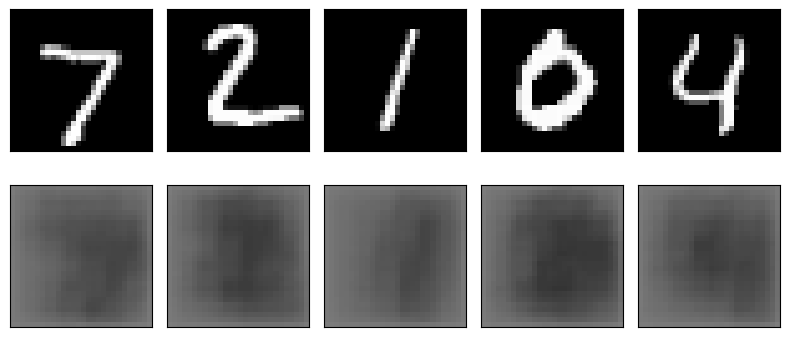

In [18]:
Conv_predictions = Conv_AE.predict(X_test)
draw_predictions_set(Conv_predictions, 'NB3-ConvAE-predictions')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
save_figure (stub) – would save 'NB3-ConvAE-noise-add-1-predictions', but skipping.


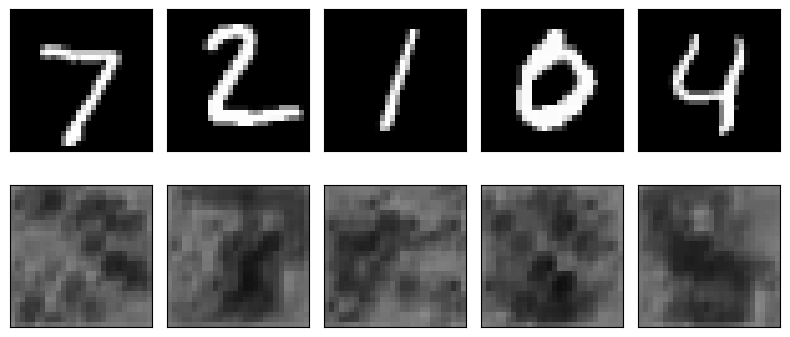

In [19]:
Conv_latents = Conv_AE_encoder_only_model.predict(X_test)
conv_noisy_in = Conv_latents.copy()[0:5]
noise = 1
for i in range(5):
    for v2 in range(7):
        for v3 in range(7):
            conv_noisy_in[i,v2,v3] += np.random.uniform(low=-noise, high=noise)
conv_noisy_predictions = Conv_AE_decoder_only_model.predict(conv_noisy_in)
conv_noisy_predictions.shape
draw_predictions_set(conv_noisy_predictions, 'NB3-ConvAE-noise-add-1')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
save_figure (stub) – would save 'NB3-ConvAE-noise-add-5-predictions', but skipping.


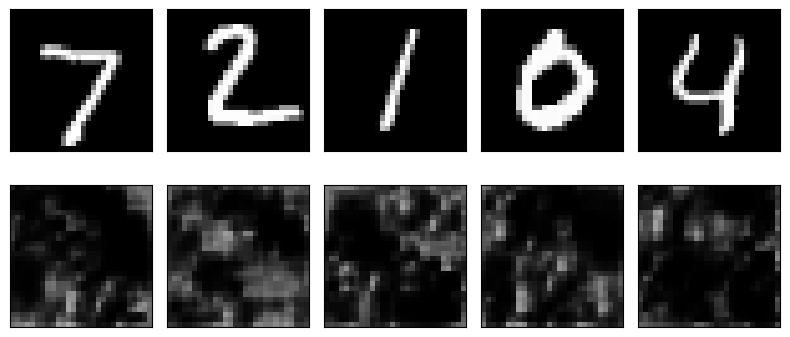

In [20]:
Conv_latents = Conv_AE_encoder_only_model.predict(X_test)
conv_noisy_in = Conv_latents.copy()[0:5]
noise = 5
for i in range(5):
    for v2 in range(7):
        for v3 in range(7):
            conv_noisy_in[i,v2,v3] += np.random.uniform(low=-noise, high=noise)
conv_noisy_predictions = Conv_AE_decoder_only_model.predict(conv_noisy_in)
conv_noisy_predictions.shape
draw_predictions_set(conv_noisy_predictions, 'NB3-ConvAE-noise-add-5')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
save_figure (stub) – would save 'NB3-ConvAE-noise-add-10-predictions', but skipping.


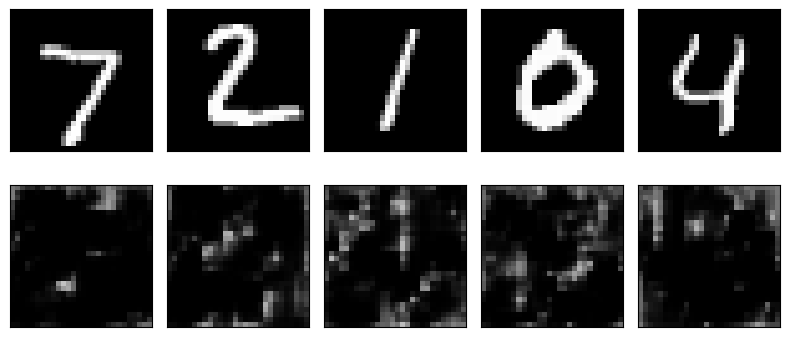

In [21]:
Conv_latents = Conv_AE_encoder_only_model.predict(X_test)
conv_noisy_in = Conv_latents.copy()[0:5]
noise = 10
for i in range(5):
    for v2 in range(7):
        for v3 in range(7):
            conv_noisy_in[i,v2,v3] += np.random.uniform(low=-noise, high=noise)
conv_noisy_predictions = Conv_AE_decoder_only_model.predict(conv_noisy_in)
conv_noisy_predictions.shape
draw_predictions_set(conv_noisy_predictions, 'NB3-ConvAE-noise-add-10')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
save_figure (stub) – would save 'NB3-ConvAE-all-noise-predictions', but skipping.


<Figure size 640x480 with 0 Axes>

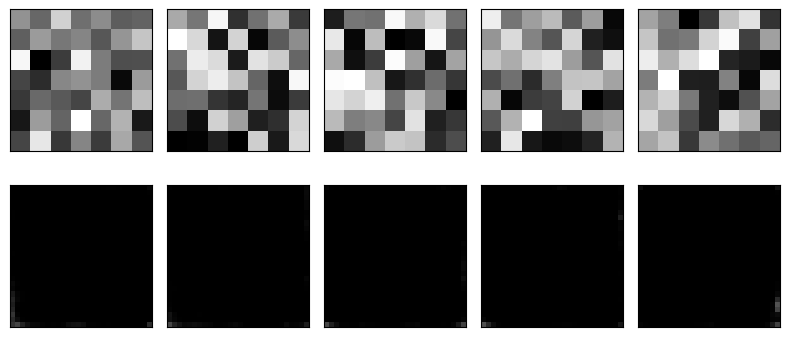

In [23]:
conv_noisy_in = np.random.uniform(low=0, high=16, size=(5*7*7*3))
conv_noisy_in = np.reshape(conv_noisy_in, (5,7,7,3))
conv_noisy_predictions = Conv_AE_decoder_only_model.predict(conv_noisy_in)

plt.clf()
plt.figure(figsize=(8, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(conv_noisy_in[i,:,:,0].reshape(7, 7), cmap="gray", interpolation='nearest')
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.subplot(2, 5, i+6)
    plt.imshow(conv_noisy_predictions[i].reshape(28, 28), vmin=0, vmax=1, cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
file_helper.save_figure(plt.gcf(), 'NB3-ConvAE-all-noise-predictions')
plt.show()

In [27]:
import os
import requests
from PIL import Image
from io import BytesIO

# Any image URL (small demo from matplotlib repo)
url = "https://raw.githubusercontent.com/matplotlib/matplotlib/main/doc/_static/stinkbug.png"

headers = {"User-Agent": "Mozilla/5.0"}
resp = requests.get(url, headers=headers)
print("HTTP status:", resp.status_code, "length:", len(resp.content))

img = Image.open(BytesIO(resp.content)).convert("L")  # grayscale
img = img.resize((28, 28))

save_path = "/content/tiger-gray-28-28.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
img.save(save_path)
print("Saved:", save_path, "exists:", os.path.exists(save_path))

# Make sure file_helper looks in /content
file_helper.INPUT_DIR = "/content"

HTTP status: 200 length: 108161
Saved: /content/tiger-gray-28-28.png exists: True


get_input_file_path (stub) -> /content/tiger-gray-28-28.png
Loading from: /content/tiger-gray-28-28.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
save_figure (stub) – would save 'NB3-ConvAE-tiger-pair', but skipping.


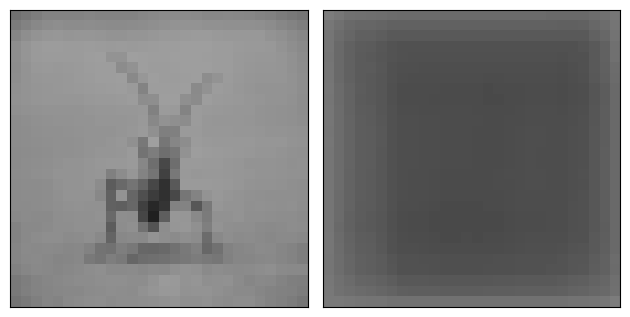

In [28]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

filepath = file_helper.get_input_file_path("tiger-gray-28-28.png")
print("Loading from:", filepath)

im = Image.open(filepath).convert("L")
pix = im.load()

tiger = np.zeros((1, 28, 28, 1), dtype=np.float32)
for y in range(28):
    for x in range(28):
        tiger[0, y, x, 0] = pix[x, y] / 255.0

predicted_tiger = Conv_AE.predict(tiger)

plt.subplot(1, 2, 1)
plt.imshow(tiger[0, :, :, 0], vmin=0, vmax=1, cmap="gray")
plt.xticks([]); plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(predicted_tiger[0, :, :, 0], vmin=0, vmax=1, cmap="gray")
plt.xticks([]); plt.yticks([])

plt.tight_layout()
file_helper.save_figure(plt.gcf(), "NB3-ConvAE-tiger-pair")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
save_figure (stub) – would save 'NB3-ConvAE-blend-grid', but skipping.


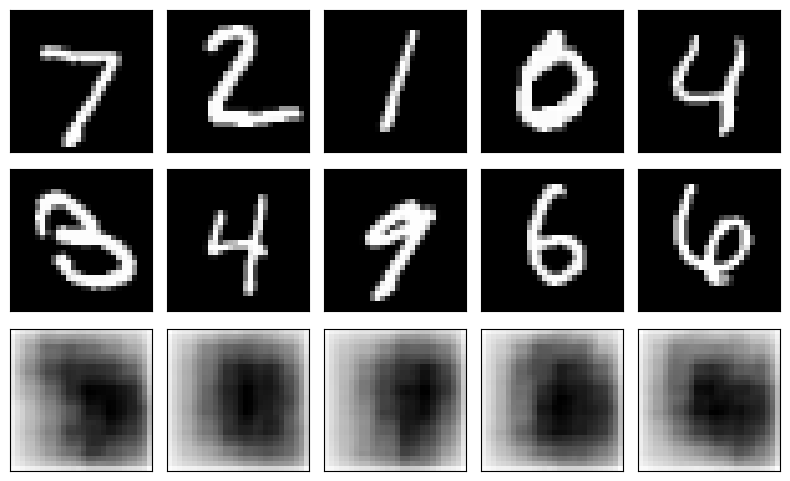

In [30]:
# blend latents for two test images and decompress
encoder_predictions = np.array(Conv_AE_encoder_only_model.predict(X_test))
np.random.seed(random_seed)

plt.figure(figsize=(8, 5))
offset = 18
for i in range(5):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    plt.subplot(3, 5, i+6)
    plt.imshow(X_test[i+offset].reshape(28, 28), cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    plt.subplot(3, 5, i+11)
    latent0 = np.reshape(encoder_predictions[i], (3*7*7,))
    latent1 = np.reshape(encoder_predictions[i+offset], (3*7*7,))
    latent_mix = [(latent0[i]+latent1[i])/2. for i in range(len(latent0))]
    latent_mix = np.reshape(latent_mix, (1,7,7,3))
    decoder_prediction = Conv_AE_decoder_only_model.predict(latent_mix)
    plt.imshow(decoder_prediction.reshape(28, 28), cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
file_helper.save_figure(plt.gcf(), "NB3-ConvAE-blend-grid")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


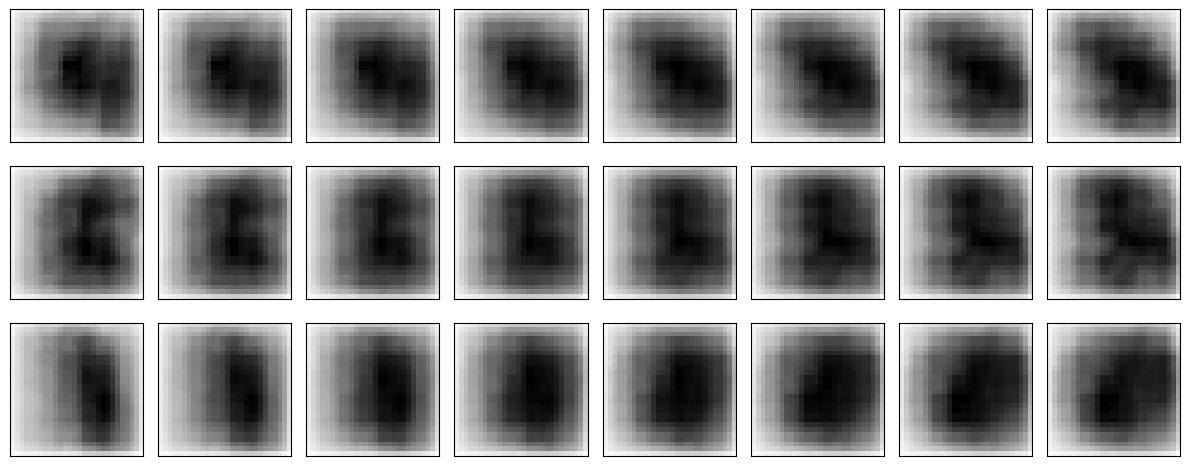

In [32]:
# blend latents for two test images and decompress
encoder_predictions = np.array(Conv_AE_encoder_only_model.predict(X_test))
np.random.seed(random_seed)

steps = 8
plt.figure(figsize=(12, 5))
latent0_list = [ encoder_predictions[4], encoder_predictions[23], encoder_predictions[29]]
latent1_list = [ encoder_predictions[18], encoder_predictions[15], encoder_predictions[25]]

for r in range(3):
    latent0 = np.reshape(latent0_list[r], (3*7*7,))
    latent1 = np.reshape(latent1_list[r], (3*7*7,))
    for i in range(steps):
        plt.subplot(3, steps, (steps*r)+(i+1))
        alpha = i/(steps-1.0)
        latent_mix = [latent0[i]+(alpha*(latent1[i]-latent0[i])) for i in range(len(latent0))]
        latent_mix = np.reshape(latent_mix, (1, 7, 7, 3))
        decoder_prediction = Conv_AE_decoder_only_model.predict(latent_mix)
        plt.imshow(decoder_prediction.reshape(28, 28), cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
plt.tight_layout()
#file_helper.save_figure("NB3-ConvAE-blend-linear")
plt.show()